# Felony Arrest and Crime Incidents - Classification Model 
## Author: Martin Ngoh 
### Date: 10/22/2024

In [2]:
# Load Packages
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [7]:
# Load Data
dfOrig = pd.read_csv('../data/combined_cleaned_data.csv')
df = dfOrig[[
    'mpd_charge_category', 'mpd_arrest_date',
    'age', 'race', 'home_state', 'is_marijuana',
    'offense_location_district', 'arrest_count'
]].copy()

# Rename columns
df = df.rename(columns={
    'mpd_charge_category': 'charge_category',
    'mpd_arrest_date': 'arrest_date',
    'offense_location_district': 'district'
})

# Drop rows with missing values
df = df.dropna()
print(f"Shape: {df.shape}")
df.head(2)

Shape: (19624, 8)


,charge_category,arrest_date,age,race,home_state,is_marijuana,district,arrest_count
0,Weapon Violations,2016/01/01 01:00:00,33,Black,DC,False,6D,5
1,Weapon Violations,2016/01/01 01:00:00,33,Black,DC,False,6D,5


In [8]:
# Convert Datetime to month and time 
df['arrest_date'] = pd.to_datetime(df['arrest_date'])
df['month'] = df['arrest_date'].dt.month
df['hour'] = df['arrest_date'].dt.hour

In [9]:
# Subset the Data 
df = df.drop('arrest_date', axis=1)
df.head(2)

,charge_category,age,race,home_state,is_marijuana,district,arrest_count,month,hour
0,Weapon Violations,33,Black,DC,False,6D,5,1,1
1,Weapon Violations,33,Black,DC,False,6D,5,1,1


## One Hot Encode Features

In [10]:
# Separate target from features before encoding
y = df['charge_category']
X = df.drop('charge_category', axis=1)

# One-hot encode categoricals (target excluded)
X = pd.get_dummies(X, columns=['race', 'home_state', 'is_marijuana', 'district'], drop_first=True)

print(f"Feature matrix: {X.shape}  |  Classes: {y.nunique()}")
X.head(2)

Feature matrix: (19624, 70)  |  Classes: 25


,age,arrest_count,month,hour,race_Asian,race_Black,race_Native Hawaiian Or Other Pacific Islander,race_Unknown,race_White,home_state_AR,...,home_state_WI,home_state_WV,is_marijuana_True,district_2D,district_3D,district_4D,district_5D,district_6D,district_7D,district_Unknown
0,33,5,1,1,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,33,5,1,1,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


## Random Forest Classification
Predict `charge_category` from demographic and location features.

In [11]:
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8155

                                    precision    recall  f1-score   support

                Aggravated Assault       0.85      0.81      0.83        96
                             Arson       1.00      1.00      1.00         1
       Assault on a Police Officer       0.65      0.61      0.63        49
   Assault with a Dangerous Weapon       0.80      0.80      0.80       491
                          Burglary       0.80      0.76      0.78       122
                Damage to Property       0.73      0.70      0.71        57
 Driving/Boating While Intoxicated       1.00      0.60      0.75         5
        Fraud and Financial Crimes       0.92      0.81      0.86        42
                          Homicide       0.72      0.64      0.68        28
                        Kidnapping       0.50      0.30      0.38        10
               Motor Vehicle Theft       0.36      0.39      0.38        23
                         Narcotics       0.80      0.83      0.82    

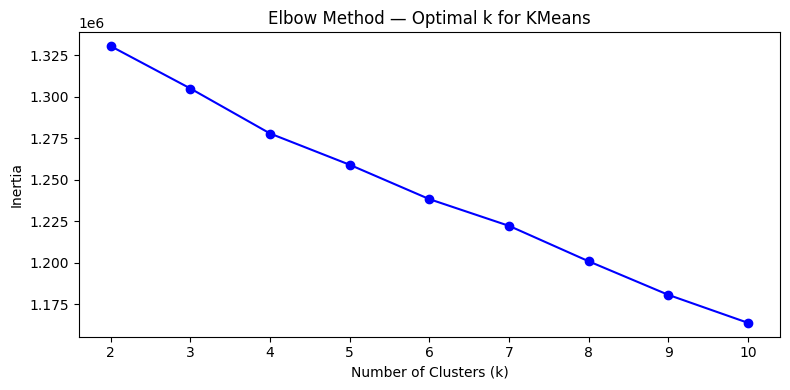

In [12]:
# Scale features for KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method — find optimal k
inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal k for KMeans')
plt.tight_layout()
plt.show()

# Fit final model with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

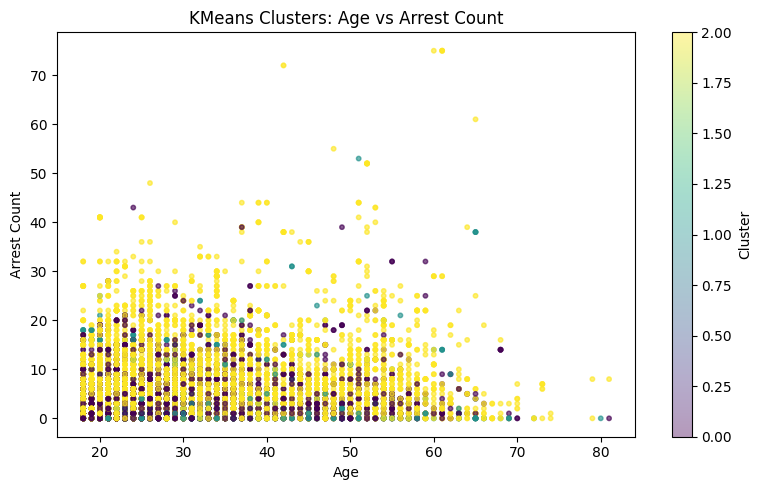

In [14]:
# Visualize clusters: Age vs Arrest Count
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    df['age'], df['arrest_count'],
    c=df['Cluster'], cmap='viridis', alpha=0.4, s=10
)
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_xlabel('Age')
ax.set_ylabel('Arrest Count')
ax.set_title('KMeans Clusters: Age vs Arrest Count')
plt.tight_layout()
plt.show()

In [ ]:
# Step 2: Feature Scaling (Standardization)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)

# Step 3: KMeans Clustering
# Define the number of clusters (k) -- you can use methods like the Elbow method to find the best k
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(data_scaled)

# Step 4: Add the Cluster Labels to the DataFrame
df['Cluster'] = clusters

# Output the resulting DataFrame
print(df)

ValueError: could not convert string to float: 'Weapon Violations'

In [16]:
# Step 5: Optional - Plotting the results (if 2 features)
# Since we have more than two features, we will visualize only a projection (let's pick Age and Income)
plt.scatter(data['Age'], data['Income'], c=data['Cluster'], cmap='viridis')
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('KMeans Clustering on Age and Income')
plt.show()

NameError: name 'data' is not defined